# Supplementary Figure S42: LR-prior and interaction ablations

Compare the full model with a model trained without the LR prior, then compare predictions with and without interaction at inference. These are the two analyses in S42.


## Before you start

Follow the [source installation](../../installation.md), then run these cells in order. The numerical inputs are included with the code. The notebook saves new figures and their calculation tables.

To generate these inputs from fitted models, see the [calculation guide](../../reference/figure_sources/interaction-ablation.md).


## Read the result tables

The LR-prior table contains paired target-level errors. The inference table contains both conditions, three paired inference seeds, and five projection repeats for each target and evaluation space.

In [1]:
import pandas as pd

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)

from pathlib import Path
import pandas as pd
from IPython.display import Image, display
from CytoBridge.results.interaction_ablation import load_interaction_ablation_results, interaction_ablation_statistics, write_interaction_ablation_tables

results = load_interaction_ablation_results()
results.no_lr.head()

,dataset,target,space,metric,full,no_lr_prior,no_lr_prior_minus_full,no_lr_prior_relative_to_full
0,zebrafish,1,joint,sliced_w2,0.027367,0.048532,0.021165,0.773384
1,zebrafish,1,spatial,sliced_w2,0.016100,0.019290,0.003190,0.198120
2,zebrafish,1,state,sliced_w2,0.027621,0.053158,0.025537,0.924544
3,zebrafish,2,joint,sliced_w2,0.038902,0.058765,0.019863,0.510584
4,zebrafish,2,spatial,sliced_w2,0.019253,0.026927,0.007674,0.398610


## Calculate the paired comparisons

For the inference comparison, average the five projection repeats within each condition and seed first. Divide the error without interaction by the error with interaction, then average these paired ratios over the three seeds. The loader performs these calculations from `inference_metrics.csv`.

Each row below is one target and evaluation space. `off_relative_to_on` is the fractional change in error. The figure expresses this as a percentage.

In [2]:
results.interaction.head()

,dataset,target,space,off_relative_to_on,interaction_on,interaction_off
0,admouse,1.0,joint,0.008722,0.014172,0.014295
1,admouse,1.0,spatial,-0.000360,0.038910,0.038896
2,admouse,1.0,state,0.015320,0.011121,0.011292
3,admouse,2.0,joint,0.036143,0.012343,0.012790
4,admouse,2.0,spatial,-0.002819,0.037669,0.037563


## Draw the figure

The plotting function draws the bars, points, and error bars from the calculated tables. It writes a vector PDF and a PNG. White points represent target stages. Error bars show the standard error across target stages, after averaging the paired inference-seed ratios.

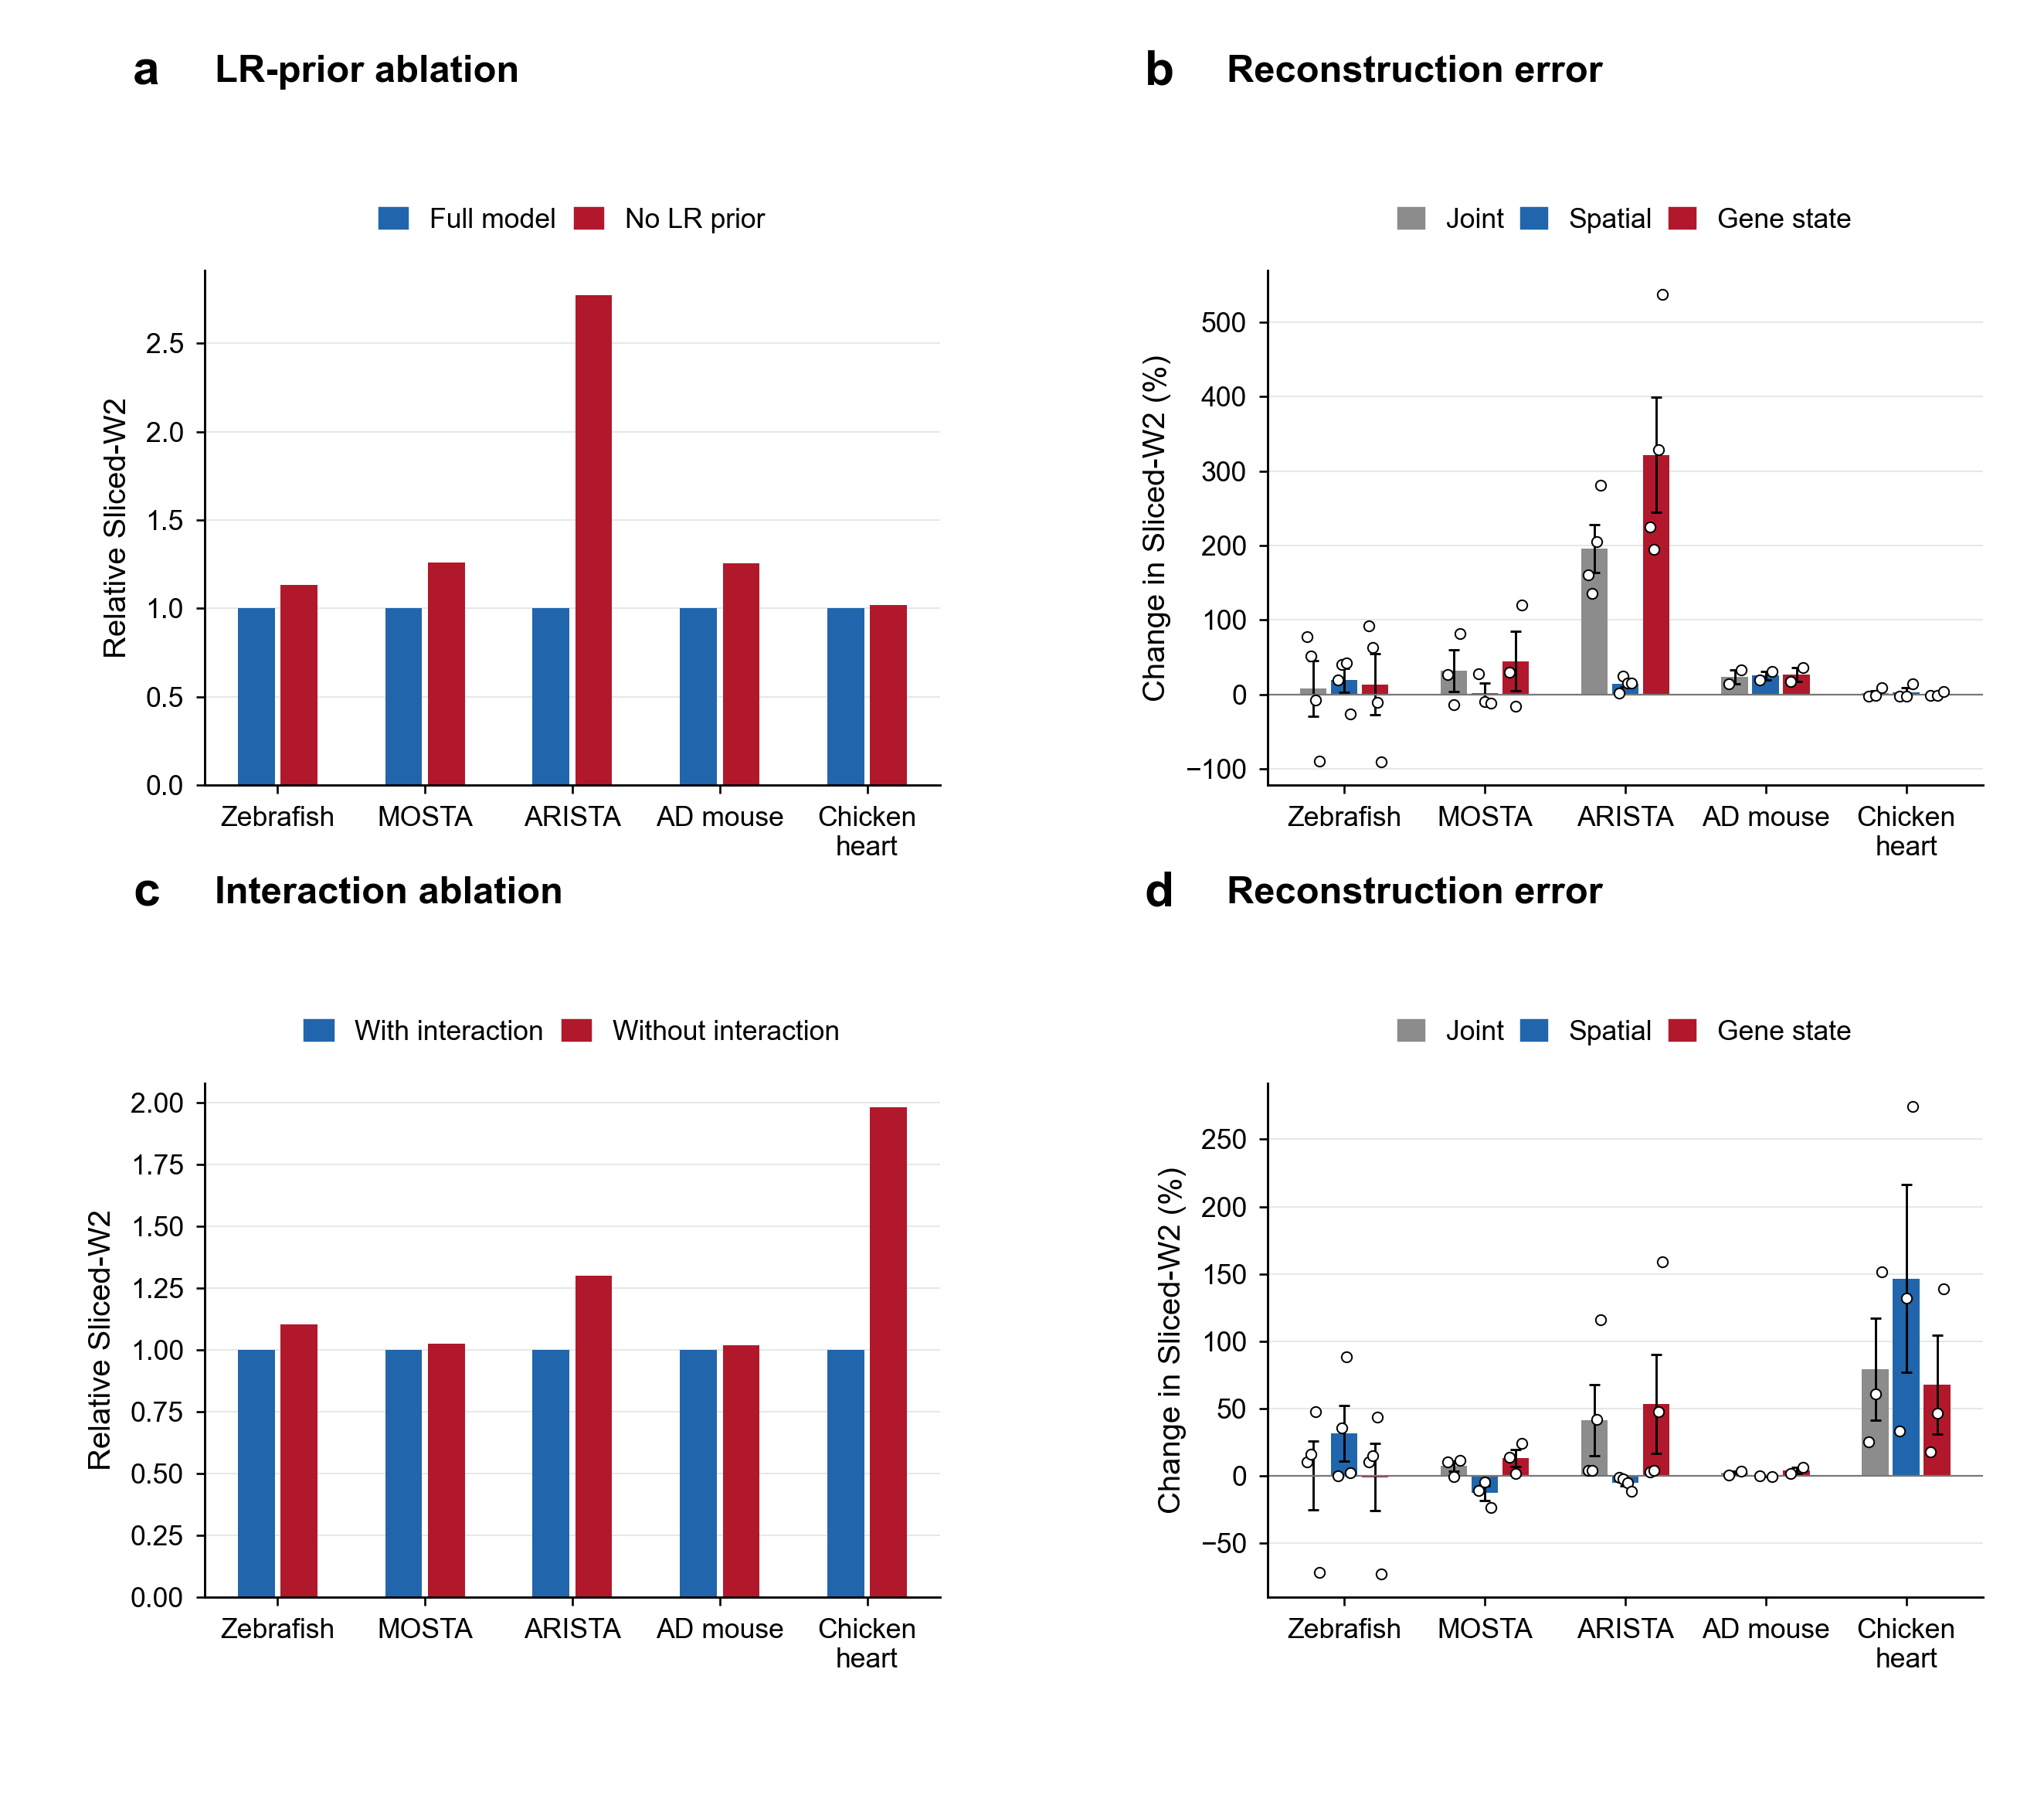

In [3]:
import os
output = Path(os.environ.get("CYTOBRIDGE_PROJECT_DIR", ".")) / "outputs" / 'interaction_ablation'
tables = write_interaction_ablation_tables(results, output)
from reproduction.paper_figures import draw_supplementary
pdf, png = draw_supplementary([42], output, results_dir=results.source_dir)["s42"]
display(Image(filename=str(png)))

In [4]:
statistics = interaction_ablation_statistics(results)
pd.DataFrame({
    'No-LR error change (%)': statistics['no_lr_dataset_percent_increase'],
    'Interaction-off error change (%)': statistics['interaction_off_dataset_percent_increase'],
}).round(1)

,No-LR error change (%),Interaction-off error change (%)
admouse,25.5,2.0
arista,177.3,30.1
chicken_heart,1.8,97.9
mosta,26.1,2.5
zebrafish,13.5,10.4


## Repeat the analysis with fitted models

Run the following commands from the repository root. Start with the Full models produced by the [dataset workflows](../dataset_workflows/index.md). For each dataset, the benchmark input manifest supplies its `full_data` split, the initial particles, and the observed targets. Its aligned input must match the model's `training_run_summary.json`.

If benchmark inputs have not yet been prepared, create them from the completed model runs:

```bash
python -m scripts.spatiotemporal_benchmark.run_unified_benchmark \
  --datasets zebrafish mosta arista admouse chicken_heart \
  --model-runs /path/to/matched-model-runs \
  --run-root /path/to/benchmark \
  prepare
```

For example, evaluate the ARISTA Full model:

```bash
python scripts/paper_figures/interaction_ablation/run_comparison.py \
  --dataset arista \
  --model-dir /path/to/arista/training \
  --input-manifest /path/to/benchmark/arista/inputs/manifest.json \
  --code-root . \
  --output outputs/interaction_inference/arista \
  --seeds 42 43 44 \
  --gpu-metrics \
  --device cuda:0
```

Repeat for `zebrafish`, `mosta`, `admouse`, and `chicken_heart`, using the corresponding model and input paths. Each command writes `metrics.csv`, `manifest.json`, and paired prediction arrays in its dataset directory.

Both conditions use the same checkpoint, initial particles, and random streams. Only the entire interaction-network output is set to zero. The intrinsic-drift, growth, and score networks are unchanged. Growth is retained as continuous particle weights without resampling. The models are not retrained for this comparison.

For panels a–b, use `paired_target_deltas.csv` from the completed Full/No-LR matched-ablation report. Training and evaluation are implemented in `scripts/run_matched_ablation_matrix.py` and `scripts/run_matched_ablation_benchmark_evaluation.py`. These scripts use the manuscript's matched model records. The No-LR model keeps the interaction network and spatial cutoff, with a radius-based graph in place of the LR-informed edge gate.

## Collect and plot new results

The collection command combines the existing LR-prior report with the five inference runs completed above:

```bash
python scripts/collect_figure_inputs.py s42 \
  --no-lr-table /path/to/matched-ablation-report/paired_target_deltas.csv \
  --inference-results-dir outputs/interaction_inference \
  --output-dir outputs/s42_inputs
```

Plot those collected results:

```bash
python -m reproduction.paper_figures --figures 42 \
  --results-dir outputs/s42_inputs \
  --output-dir outputs/s42
```

Alternatively, pass `outputs/s42_inputs` to `load_interaction_ablation_results` above and rerun the plotting cells.

All models in this figure were fitted using all measured stages. These comparisons evaluate reconstruction of observed populations. The separate held-out method comparison, including stVCR, is in [Supplementary Figure S45](loto_benchmark.ipynb).